In [1]:
import os, sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.experiments import impls

In [2]:
# Set the current working directory
cwd = os.getcwd()

In [8]:
# Load relevant data
G_frac = [0.1, 0.3, 1.0]

freqP_data_list = []
PL_data_list = []

# Load the freqP data for all data with matrix calculation enabled
for g_frac in G_frac:
    genProfile = 'calc'
    uuid = 'genProfile_' + genProfile +'_gFrac_' + str(g_frac) 
    file_name = 'freqP_' + uuid + '.dat'
    data = pd.read_csv(file_name, sep=r'\s+')
    data_dict = {
        "file_name" : file_name,
        "genProfile" : genProfile,
        "G_frac" : g_frac,
        "data" : data
    }
    
    freqP_data_list.append(data_dict)

# Load PL data for all data with matrix calculation enabled 
for g_frac in G_frac:
    genProfile = 'calc'
    uuid = 'genProfile_' + genProfile +'_gFrac_' + str(g_frac) 
    file_name = 'tPL_' + uuid + '.dat'
    data = pd.read_csv(file_name, sep=r'\s+')
    data_dict = {
        "file_name" : file_name,
        "genProfile" : genProfile,
        "G_frac" : g_frac,
        "data" : data
    }
    
    PL_data_list.append(data_dict)
    
# Load the freqP data for all data without matrix calculation enabled
genProfile = 'none'
uuid = 'genProfile_' + genProfile +'_gFrac_' + '1.0' 
file_name = 'freqP_' + uuid + '.dat'
data = pd.read_csv(file_name, sep=r'\s+')
data_dict = {
    "file_name" : file_name,
    "genProfile" : genProfile,
    "G_frac" : g_frac,
    "data" : data
}
freqP_data_list.append(data_dict)

# Load tPL for all data without matrix calculation enabled
genProfile = 'none'
uuid = 'genProfile_' + genProfile +'_gFrac_' + '1.0' 
file_name = 'tPL_' + uuid + '.dat'
data = pd.read_csv(file_name, sep=r'\s+')
data_dict = {
    "file_name" : file_name,
    "genProfile" : genProfile,
    "G_frac" : g_frac,
    "data" : data
}
PL_data_list.append(data_dict)

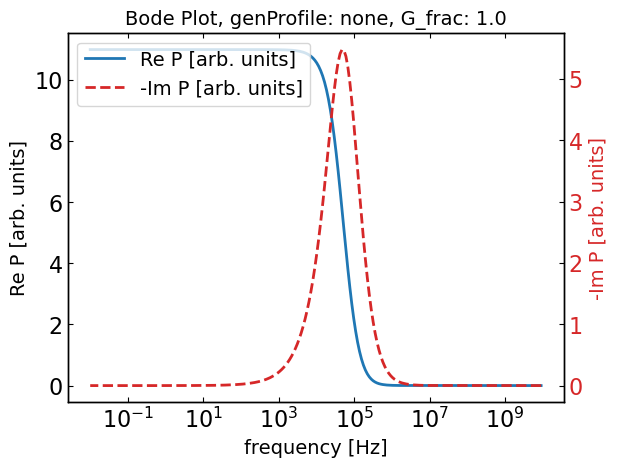

In [9]:
# Print out the non-asymmetric lighting data
freqP_data = freqP_data_list[-1]
genProfile = freqP_data['genProfile']
G_frac = freqP_data['G_frac']
impls.IMPLS_plot(cwd, freqP_data['file_name'], yscale1='linear', yscale2='linear', title=f"Bode Plot, genProfile: {genProfile}, G_frac: {G_frac}")

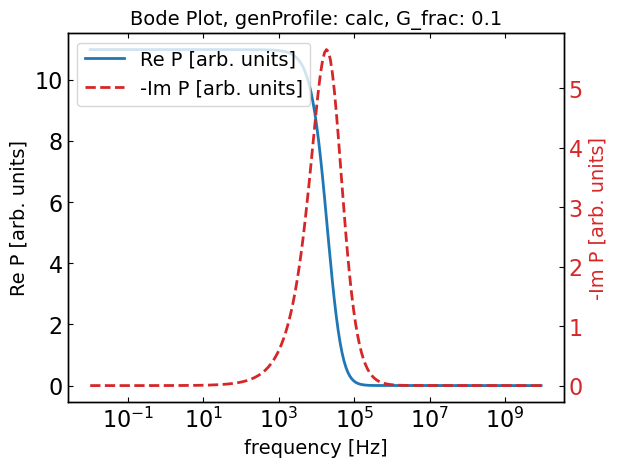

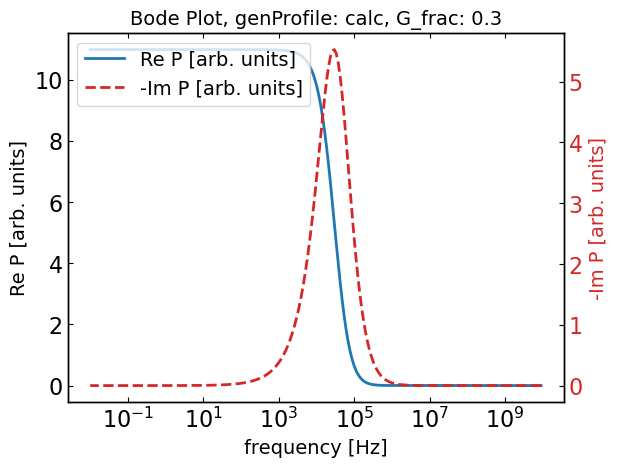

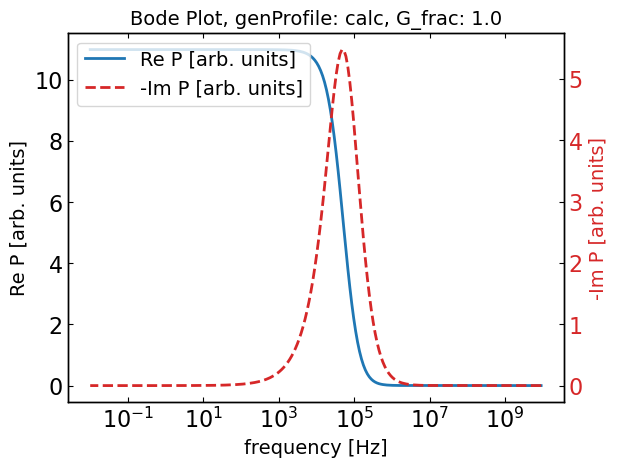

In [10]:
for freqP_data in freqP_data_list[0:3]:
    genProfile = freqP_data['genProfile']
    G_frac = freqP_data['G_frac']
    impls.IMPLS_plot(cwd, freqP_data['file_name'], yscale1='linear', yscale2='linear', title=f"Bode Plot, genProfile: {genProfile}, G_frac: {G_frac}")

In [11]:
# Using standard Nyquist plot techniques, find the lifetime for each of these plots
for freqP_data in freqP_data_list:
    # Find the peak frequency of Im P, as this corresponds to the characteristic RC frequency of the optical equivalent circuit (OEC)
    max_ImP = freqP_data['data']['ImP'].abs().max()
    max_row = freqP_data['data'][freqP_data['data']['ImP'].abs() == max_ImP]
    max_freq = max_row['freq'].values[0]
    freqP_data['char_freq'] = max_freq
    freqP_data['char_lifetime'] = 1/(2*np.pi*max_freq)
    print(f"GenProfile: {freqP_data['genProfile']}   Frac: {freqP_data['G_frac']}   Char_tau: {freqP_data['char_lifetime']}")


GenProfile: calc   Frac: 0.1   Char_tau: 8.624606003053896e-06
GenProfile: calc   Frac: 0.3   Char_tau: 5.361929732497889e-06
GenProfile: calc   Frac: 1.0   Char_tau: 3.334295841045978e-06
GenProfile: none   Frac: 1.0   Char_tau: 3.334295841045978e-06
